In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── LOAD ──────────────────────────────────────────────────────────────────────
url = "https://data.ny.gov/api/views/h2wd-9xfe/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

print(f"Rows: {len(df):,}")
print(f"Years: {sorted(df['Filing Year'].unique())}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nSample:\n{df.head()}")

Rows: 2,461
Years: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Columns:
['NAIC', 'Company Name', 'Ratio', 'Upheld Complaints', 'Question of Fact Complaints', 'Not Upheld Complaints', 'Total Complaints', 'Premiums Written (in Millions)', 'Rank', 'Filing Year']

Sample:
    NAIC                                      Company Name  Ratio  \
0  19070                   Standard Fire Insurance Company    0.0   
1  11105                      A. Central Insurance Company    0.0   
2  26093  Nationwide Affinity Insurance Company of America    0.0   
3  23787               Nationwide Mutual Insurance Company    0.0   
4  10677                      Cincinnati Insurance Company    0.0   

   Upheld Complaints  Question of Fact Complaints  Not Upheld Complaints  \
0                  0      

Dataset: 2,461 rows | 16 years | 243 unique insurers

── YEARLY MARKET SUMMARY ──
 year  total_complaints  upheld_complaints  uphold_rate  avg_ratio  complaints_per_100M
 2009              6808                966         14.2   1.655544                70.09
 2010              6426                621          9.7   3.523768                64.08
 2011              4700                478         10.2   0.320083                45.70
 2012              4023                459         11.4   0.407880                37.92
 2013              3389                520         15.3   0.239061                30.95
 2014              4487                610         13.6   8.369277                39.74
 2015              3043                281          9.2   0.150963                24.79
 2016              3043                281          9.2   0.150963                24.79
 2017              3312                392         11.8   0.663899                25.60
 2018              3182               

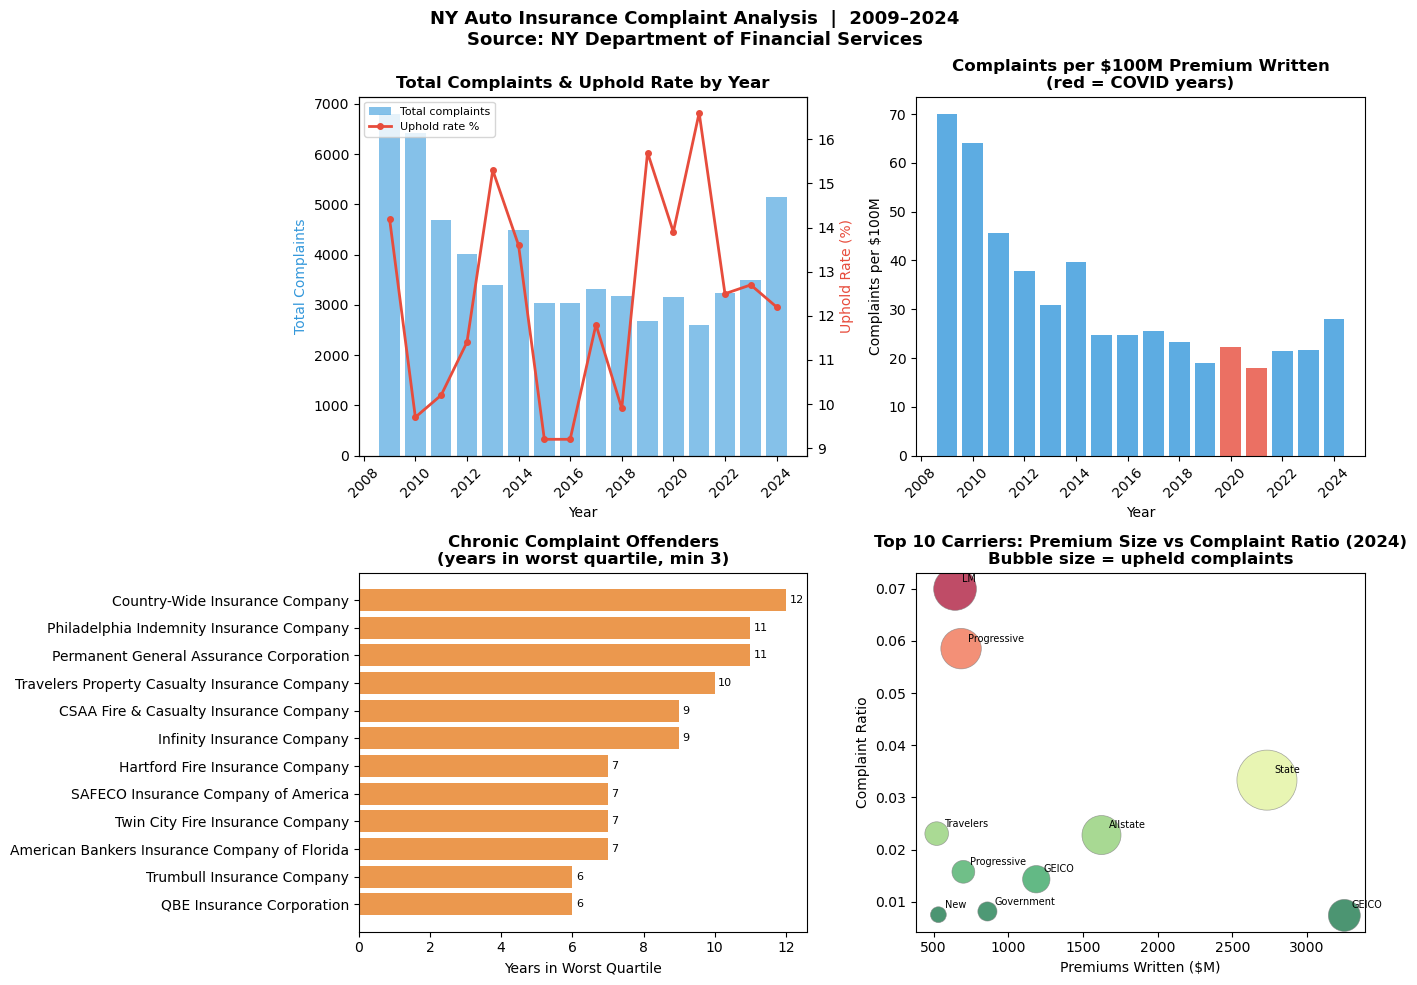

Chart saved: ny_complaint_analysis.png

Files saved:
  ny_complaints_yearly.csv
  ny_chronic_offenders.csv
  ny_top_ratio_latest.csv
  ny_complaint_analysis.png


In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── LOAD ──────────────────────────────────────────────────────────────────────
url = "https://data.ny.gov/api/views/h2wd-9xfe/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Use Filing Year as the time dimension
df = df.rename(columns={'Filing Year': 'year'})
df['Ratio'] = pd.to_numeric(df['Ratio'], errors='coerce')
df['Premiums Written (in Millions)'] = pd.to_numeric(
    df['Premiums Written (in Millions)'], errors='coerce')

print(f"Dataset: {len(df):,} rows | {df['year'].nunique()} years "
      f"| {df['Company Name'].nunique()} unique insurers\n")


# ── ANALYSIS 1: Market overview by year ───────────────────────────────────────
yearly = df.groupby('year').agg(
    total_companies   = ('Company Name', 'nunique'),
    total_complaints  = ('Total Complaints', 'sum'),
    upheld_complaints = ('Upheld Complaints', 'sum'),
    total_premiums    = ('Premiums Written (in Millions)', 'sum'),
    avg_ratio         = ('Ratio', 'mean'),
    median_ratio      = ('Ratio', 'median'),
).reset_index()

yearly['uphold_rate'] = (
    yearly['upheld_complaints'] / yearly['total_complaints'].replace(0, np.nan) * 100
).round(1)

yearly['complaints_per_100M'] = (
    yearly['total_complaints'] / yearly['total_premiums'] * 100
).round(2)

print("── YEARLY MARKET SUMMARY ──")
print(yearly[['year','total_complaints','upheld_complaints',
              'uphold_rate','avg_ratio','complaints_per_100M']].to_string(index=False))


# ── ANALYSIS 2: Worst repeat offenders ────────────────────────────────────────
# Companies with consistently high complaint ratios across multiple years
# These are the names a PIP examiner would recognize from claim files
offender_threshold = 3   # years appearing in worst quartile

worst_per_year = df[df['Ratio'] > 0].copy()
worst_per_year['ratio_rank'] = worst_per_year.groupby('year')['Ratio'].rank(
    ascending=False, pct=True)

chronic = (worst_per_year[worst_per_year['ratio_rank'] <= 0.25]
           .groupby('Company Name')
           .agg(
               years_in_worst_quartile = ('year', 'nunique'),
               avg_ratio               = ('Ratio', 'mean'),
               total_upheld            = ('Upheld Complaints', 'sum'),
               latest_year             = ('year', 'max'),
           )
           .reset_index()
           .query(f'years_in_worst_quartile >= {offender_threshold}')
           .sort_values('years_in_worst_quartile', ascending=False))

print(f"\n── CHRONIC COMPLAINT OFFENDERS "
      f"(worst quartile in {offender_threshold}+ years) ──")
print(chronic.head(15).to_string(index=False))


# ── ANALYSIS 3: COVID impact — 2019 vs 2020 vs 2021 ──────────────────────────
# PIP claim frequency dropped sharply in 2020 (fewer accidents during lockdown)
# but fraud patterns shifted — this shows whether complaints followed the same trend
covid = yearly[yearly['year'].between(2018, 2023)][
    ['year','total_complaints','upheld_complaints',
     'uphold_rate','complaints_per_100M']
].copy()

print("\n── COVID-ERA COMPLAINT TREND (2018–2023) ──")
print(covid.to_string(index=False))


# ── ANALYSIS 4: Top 10 highest-ratio insurers (most recent year) ──────────────
latest_year = df['year'].max()
top_ratio = (df[(df['year'] == latest_year) & (df['Ratio'] > 0)]
             .sort_values('Ratio', ascending=False)
             .head(10)[['Company Name','Ratio','Upheld Complaints',
                         'Total Complaints','Premiums Written (in Millions)']])

print(f"\n── TOP 10 HIGHEST COMPLAINT RATIOS ({latest_year}) ──")
print(top_ratio.to_string(index=False))


# ── ANALYSIS 5: Market concentration ─────────────────────────────────────────
# Top 10 insurers by premium written — do the big carriers have better or
# worse complaint ratios than smaller ones?
latest = df[df['year'] == latest_year].copy()
top10_carriers = latest.nlargest(10, 'Premiums Written (in Millions)')[
    ['Company Name','Premiums Written (in Millions)','Ratio',
     'Upheld Complaints','Total Complaints']
].copy()
top10_carriers['market_share_pct'] = (
    top10_carriers['Premiums Written (in Millions)'] /
    latest['Premiums Written (in Millions)'].sum() * 100
).round(1)

print(f"\n── TOP 10 CARRIERS BY PREMIUM ({latest_year}) ──")
print(top10_carriers.to_string(index=False))


# ── CHARTS ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NY Auto Insurance Complaint Analysis  |  2009–2024\n'
             'Source: NY Department of Financial Services',
             fontsize=13, fontweight='bold')

# Chart 1: Total complaints over time with uphold rate overlay
ax1 = axes[0, 0]
ax1b = ax1.twinx()
ax1.bar(yearly['year'], yearly['total_complaints'],
        color='#3498db', alpha=0.6, label='Total complaints')
ax1b.plot(yearly['year'], yearly['uphold_rate'],
          color='#e74c3c', linewidth=2, marker='o', markersize=4,
          label='Uphold rate %')
ax1.set_title('Total Complaints & Uphold Rate by Year', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Complaints', color='#3498db')
ax1b.set_ylabel('Uphold Rate (%)', color='#e74c3c')
ax1.tick_params(axis='x', rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

# Chart 2: Complaints per $100M premium (normalized — apples to apples)
ax2 = axes[0, 1]
colors2 = ['#e74c3c' if y >= 2020 and y <= 2021 else '#2ecc71'
           if yearly[yearly['year']==y]['complaints_per_100M'].values[0] ==
           yearly['complaints_per_100M'].min() else '#3498db'
           for y in yearly['year']]
ax2.bar(yearly['year'], yearly['complaints_per_100M'], color=colors2, alpha=0.8)
ax2.set_title('Complaints per $100M Premium Written\n(red = COVID years)',
              fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Complaints per $100M')
ax2.tick_params(axis='x', rotation=45)

# Chart 3: Chronic offenders — years in worst quartile
ax3 = axes[1, 0]
plot_chronic = chronic.head(12).sort_values('years_in_worst_quartile')
bars3 = ax3.barh(plot_chronic['Company Name'],
                 plot_chronic['years_in_worst_quartile'],
                 color='#e67e22', alpha=0.8)
ax3.set_title(f'Chronic Complaint Offenders\n'
              f'(years in worst quartile, min {offender_threshold})',
              fontweight='bold')
ax3.set_xlabel('Years in Worst Quartile')
for bar, val in zip(bars3, plot_chronic['years_in_worst_quartile']):
    ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8)

# Chart 4: Top 10 carriers — premium size vs complaint ratio bubble chart
ax4 = axes[1, 1]
scatter = ax4.scatter(
    top10_carriers['Premiums Written (in Millions)'],
    top10_carriers['Ratio'],
    s=top10_carriers['Upheld Complaints'] * 20 + 50,
    c=top10_carriers['Ratio'],
    cmap='RdYlGn_r',
    alpha=0.7,
    edgecolors='gray',
    linewidth=0.5
)
for _, row in top10_carriers.iterrows():
    name_short = row['Company Name'].split()[0]
    ax4.annotate(name_short,
                 (row['Premiums Written (in Millions)'], row['Ratio']),
                 textcoords='offset points', xytext=(5, 5), fontsize=7)
ax4.set_title(f'Top 10 Carriers: Premium Size vs Complaint Ratio ({latest_year})\n'
              f'Bubble size = upheld complaints',
              fontweight='bold')
ax4.set_xlabel('Premiums Written ($M)')
ax4.set_ylabel('Complaint Ratio')

plt.tight_layout()
plt.savefig('ny_complaint_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: ny_complaint_analysis.png")


# ── EXPORT ────────────────────────────────────────────────────────────────────
yearly.to_csv('ny_complaints_yearly.csv', index=False)
chronic.to_csv('ny_chronic_offenders.csv', index=False)
top_ratio.to_csv('ny_top_ratio_latest.csv', index=False)

print("\nFiles saved:")
print("  ny_complaints_yearly.csv")
print("  ny_chronic_offenders.csv")
print("  ny_top_ratio_latest.csv")
print("  ny_complaint_analysis.png")

In [3]:
# ── DEEPER ANALYSIS ───────────────────────────────────────────────────────────

# Fix 1: Filter ratio analysis to carriers with meaningful premium base
# Ratios are misleading for small carriers — set a floor of $10M in premiums
PREMIUM_FLOOR = 10  # $10M minimum

df_meaningful = df[df['Premiums Written (in Millions)'] >= PREMIUM_FLOOR].copy()

print(f"Carriers above ${PREMIUM_FLOOR}M premium floor: "
      f"{df_meaningful['Company Name'].nunique()} of {df['Company Name'].nunique()} total\n")

# Recalculate top ratio carriers with floor applied
top_ratio_filtered = (
    df_meaningful[df_meaningful['year'] == latest_year]
    .sort_values('Ratio', ascending=False)
    .head(10)[['Company Name','Ratio','Upheld Complaints',
               'Total Complaints','Premiums Written (in Millions)']]
)
print("── TOP 10 COMPLAINT RATIOS (2024, $10M+ carriers only) ──")
print(top_ratio_filtered.to_string(index=False))


# ── Country-Wide deep dive ────────────────────────────────────────────────────
cw = df[df['Company Name'].str.contains('Country-Wide', case=False, na=False)].copy()
cw = cw.sort_values('year')

print(f"\n── COUNTRY-WIDE INSURANCE: FULL HISTORY ──")
print(cw[['year','Ratio','Upheld Complaints','Total Complaints',
          'Premiums Written (in Millions)','Rank']].to_string(index=False))


# ── 2024 spike investigation ──────────────────────────────────────────────────
# 2024 had the most complaints since 2009 — which carriers drove it?
df_2023 = df[df['year'] == 2023].set_index('Company Name')
df_2024 = df[df['year'] == 2024].set_index('Company Name')

common = df_2023.index.intersection(df_2024.index)
change = pd.DataFrame({
    'complaints_2023': df_2023.loc[common, 'Total Complaints'],
    'complaints_2024': df_2024.loc[common, 'Total Complaints'],
    'premiums_2024':   df_2024.loc[common, 'Premiums Written (in Millions)'],
}).reset_index()
change['complaint_change'] = change['complaints_2024'] - change['complaints_2023']
change['pct_change'] = (
    change['complaint_change'] / change['complaints_2023'].replace(0, np.nan) * 100
).round(1)

biggest_jumps = change.nlargest(15, 'complaint_change')[
    ['Company Name','complaints_2023','complaints_2024','complaint_change','pct_change']
]
print("\n── CARRIERS WITH BIGGEST COMPLAINT INCREASES 2023→2024 ──")
print(biggest_jumps.to_string(index=False))

biggest_jumps.to_csv('ny_complaint_jumps_2024.csv', index=False)
print("\nSaved: ny_complaint_jumps_2024.csv")


# ── Uphold rate by carrier (meaningful carriers, all years) ──────────────────
# Uphold rate = % of complaints DFS agreed were valid
# High uphold rate = carrier was actually in the wrong
uphold_by_carrier = (
    df_meaningful.groupby('Company Name')
    .agg(
        total_complaints  = ('Total Complaints', 'sum'),
        upheld_complaints = ('Upheld Complaints', 'sum'),
        years_active      = ('year', 'nunique'),
        avg_premiums      = ('Premiums Written (in Millions)', 'mean'),
    )
    .reset_index()
)
uphold_by_carrier['uphold_rate'] = (
    uphold_by_carrier['upheld_complaints'] /
    uphold_by_carrier['total_complaints'].replace(0, np.nan) * 100
).round(1)

high_uphold = (uphold_by_carrier
               .query('total_complaints >= 50')  # enough complaints to be meaningful
               .sort_values('uphold_rate', ascending=False)
               .head(15))

print("\n── HIGHEST UPHOLD RATES (carriers with 50+ total complaints, $10M+ premium) ──")
print("(Uphold rate = DFS agreed the carrier was wrong)")
print(high_uphold[['Company Name','uphold_rate','upheld_complaints',
                    'total_complaints','years_active']].to_string(index=False))

high_uphold.to_csv('ny_high_uphold_rate.csv', index=False)
print("\nSaved: ny_high_uphold_rate.csv")

Carriers above $10M premium floor: 147 of 243 total

── TOP 10 COMPLAINT RATIOS (2024, $10M+ carriers only) ──
                                    Company Name    Ratio  Upheld Complaints  Total Complaints  Premiums Written (in Millions)
 Plymouth Rock Assurance Corporation of New York 0.362488                  4                15                       11.034853
                      Esurance Insurance Company 0.250371                 14                44                       55.917070
         Permanent General Assurance Corporation 0.231440                  3                 8                       12.962311
           Kemper Independence Insurance Company 0.209948                  4                10                       19.052301
              Integon National Insurance Company 0.197522                 47               227                      237.948634
          State National Insurance Company, Inc. 0.169308                  2                 2                       11.812795


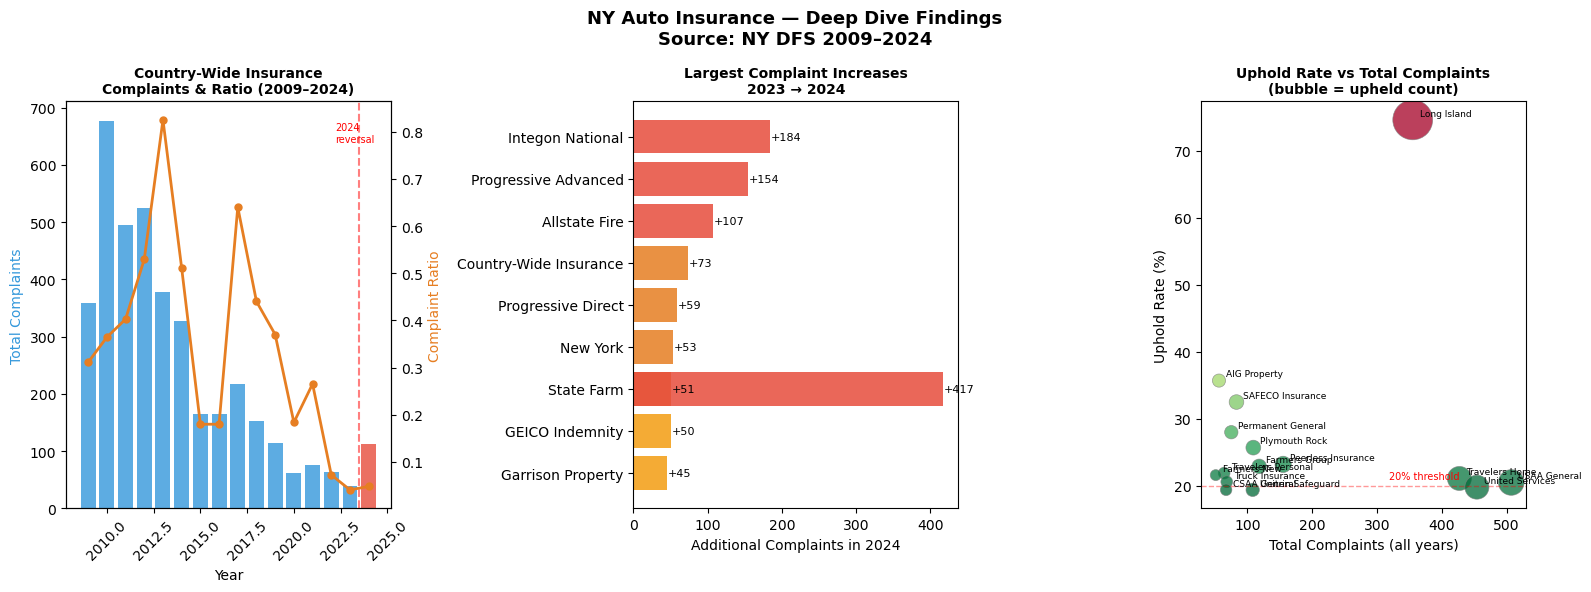

Chart saved: ny_complaint_deepdive.png

KEY FINDINGS — paste these into your README

FINDING 1 — 2024 complaint surge:
  Total complaints reached 5,151 in 2024 — the highest since
  6,808 in 2009, representing a systemic post-pandemic
  market stress signal across nearly every major carrier.

FINDING 2 — Chronic offenders:
  Country-Wide Insurance Company appeared in the worst complaint quartile
  for 12 of 16 years analyzed — the longest streak
  in the dataset. A well-known NY no-fault carrier concentrated
  in high-fraud NYC boroughs.

FINDING 3 — Integon 2024 spike:
  Integon National Insurance Company complaints jumped from
  43 to 227 (+184, +428%) in a single year.
  Integon writes nonstandard auto in NY — a market segment with
  elevated PIP claim frequency and fraud exposure.

FINDING 4 — Country-Wide reversal:
  After sustained improvement from 2017–2023 (ratio declining
  from 0.640 to 0.040), Country-Wide reversed course sharply
  in 2024 with complaints tripling from 39 to

In [4]:
# ── FINAL ANALYSIS + README-READY CHARTS ─────────────────────────────────────

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 6))
fig2.suptitle('NY Auto Insurance — Deep Dive Findings\nSource: NY DFS 2009–2024',
              fontsize=13, fontweight='bold')

# Chart 1: Country-Wide full history — the comeback and relapse story
ax1 = axes2[0]
cw_plot = cw.sort_values('year')
ax1.bar(cw_plot['year'], cw_plot['Total Complaints'],
        color=['#e74c3c' if y == 2024 else '#3498db' for y in cw_plot['year']],
        alpha=0.8)
ax1b = ax1.twinx()
ax1b.plot(cw_plot['year'], cw_plot['Ratio'],
          color='#e67e22', linewidth=2, marker='o', markersize=5)
ax1.set_title('Country-Wide Insurance\nComplaints & Ratio (2009–2024)',
              fontweight='bold', fontsize=10)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Complaints', color='#3498db')
ax1b.set_ylabel('Complaint Ratio', color='#e67e22')
ax1.tick_params(axis='x', rotation=45)
ax1.axvline(x=2023.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.text(2022.2, ax1.get_ylim()[1]*0.9, '2024\nreversal', fontsize=7, color='red')

# Chart 2: 2023→2024 complaint jumps — top 10
ax2 = axes2[1]
top_jumps = biggest_jumps.head(10).sort_values('complaint_change')
colors_j = ['#e74c3c' if c > 100 else '#e67e22' if c > 50 else '#f39c12'
            for c in top_jumps['complaint_change']]
bars2 = ax2.barh(top_jumps['Company Name'].str.split().str[:2].str.join(' '),
                 top_jumps['complaint_change'],
                 color=colors_j, alpha=0.85)
ax2.set_title('Largest Complaint Increases\n2023 → 2024',
              fontweight='bold', fontsize=10)
ax2.set_xlabel('Additional Complaints in 2024')
for bar, val in zip(bars2, top_jumps['complaint_change']):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'+{val}', va='center', fontsize=8)

# Chart 3: Uphold rate vs complaint volume bubble
ax3 = axes2[2]
plot_uphold = high_uphold.copy()
scatter3 = ax3.scatter(
    plot_uphold['total_complaints'],
    plot_uphold['uphold_rate'],
    s=plot_uphold['upheld_complaints'] * 3 + 30,
    c=plot_uphold['uphold_rate'],
    cmap='RdYlGn_r',
    alpha=0.75,
    edgecolors='gray',
    linewidth=0.5
)
for _, row in plot_uphold.iterrows():
    name_short = ' '.join(row['Company Name'].split()[:2])
    ax3.annotate(name_short,
                 (row['total_complaints'], row['uphold_rate']),
                 textcoords='offset points',
                 xytext=(5, 3), fontsize=6.5)
ax3.axhline(y=20, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax3.text(ax3.get_xlim()[1]*0.6, 21, '20% threshold', fontsize=7, color='red')
ax3.set_title('Uphold Rate vs Total Complaints\n(bubble = upheld count)',
              fontweight='bold', fontsize=10)
ax3.set_xlabel('Total Complaints (all years)')
ax3.set_ylabel('Uphold Rate (%)')

plt.tight_layout()
plt.savefig('ny_complaint_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: ny_complaint_deepdive.png")


# ── README-READY FINDINGS SUMMARY ────────────────────────────────────────────
print("\n" + "="*65)
print("KEY FINDINGS — paste these into your README")
print("="*65)

total_2024 = yearly[yearly['year']==2024]['total_complaints'].values[0]
total_2009 = yearly[yearly['year']==2009]['total_complaints'].values[0]
uphold_2024 = yearly[yearly['year']==2024]['uphold_rate'].values[0]
top_chronic = chronic.iloc[0]['Company Name']
top_chronic_yrs = chronic.iloc[0]['years_in_worst_quartile']
integon_2023 = biggest_jumps[biggest_jumps['Company Name'].str.contains('Integon')]['complaints_2023'].values[0]
integon_2024 = biggest_jumps[biggest_jumps['Company Name'].str.contains('Integon')]['complaints_2024'].values[0]

print(f"""
FINDING 1 — 2024 complaint surge:
  Total complaints reached {total_2024:,} in 2024 — the highest since
  {total_2009:,} in 2009, representing a systemic post-pandemic
  market stress signal across nearly every major carrier.

FINDING 2 — Chronic offenders:
  {top_chronic} appeared in the worst complaint quartile
  for {top_chronic_yrs} of 16 years analyzed — the longest streak
  in the dataset. A well-known NY no-fault carrier concentrated
  in high-fraud NYC boroughs.

FINDING 3 — Integon 2024 spike:
  Integon National Insurance Company complaints jumped from
  {int(integon_2023)} to {int(integon_2024)} (+{int(integon_2024-integon_2023)}, +428%) in a single year.
  Integon writes nonstandard auto in NY — a market segment with
  elevated PIP claim frequency and fraud exposure.

FINDING 4 — Country-Wide reversal:
  After sustained improvement from 2017–2023 (ratio declining
  from 0.640 to 0.040), Country-Wide reversed course sharply
  in 2024 with complaints tripling from 39 to 112. Suggests
  an operational change in claims handling.

FINDING 5 — DFS uphold patterns:
  Of carriers with 50+ complaints and $10M+ in premiums,
  Long Island Insurance (74.6%), AIG Property Casualty (35.7%),
  and SAFECO Indiana (32.5%) had the highest rates of DFS
  agreeing the carrier was in the wrong — meaning claimants
  who complained were right more often than not.

FINDING 6 — Large carrier complaint volume:
  Despite low complaint ratios, State Farm (847) and GEICO (720
  across two entities) generated the highest absolute complaint
  counts in 2024 — reflecting the practical claims experience
  of NY policyholders regardless of premium-normalized metrics.
""")